# 🛍️ Customer Segmentation & Recommendation System

**A full pipeline from raw transaction logs to actionable customer segments and product recommendations.**

This project analyzes **541,908 transactions** from a UK-based online retailer (Dec 2010 – Dec 2011) to answer three business questions:

1. **What does the data actually look like, and where is it messy?** → Exploratory Data Analysis
2. **Who are our customers, behaviorally?** → RFM feature engineering + PCA + K-Means clustering, validated via the elbow method, silhouette analysis, and cluster-predictive classification
3. **What should we recommend them?** → A hybrid recommendation engine combining collaborative filtering and content-based filtering

---

### 📑 Table of Contents
1. [Setup](#setup)
2. [Loading the Data](#load)
3. [Exploratory Data Analysis](#eda)
4. [Data Cleaning](#cleaning)
5. [RFM Feature Engineering](#rfm)
6. [Outlier Handling](#outliers)
7. [Correlation Analysis](#correlation)
8. [Scaling & PCA](#pca)
9. [Determining Optimal K](#optimal_k)
10. [Final Clustering](#clustering)
11. [Cluster Profiling (Radar Charts)](#profiling)
12. [Cluster Validation (Classifier + Confusion Matrix)](#validation)
13. [Recommendation System](#recsys)
14. [Conclusion](#conclusion)

---

**Tech stack:** `Python` · `Pandas` · `NumPy` · `Scikit-learn` · `Matplotlib` · `Seaborn`


<a id='setup'></a>
## 1. Setup

In [31]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              calinski_harabasz_score, davies_bouldin_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# --- Visual theme ---
PALETTE = ['#2E5EAA', '#4FB0C6', '#F2A541', '#D64550', '#6A4C93']
sns.set_theme(style='whitegrid', rc={'axes.facecolor': '#FAFAFA'})
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.random.seed(42)

print('Environment ready.')


Environment ready.


<a id='load'></a>
## 2. Loading the Data

Dataset: [UCI Online Retail Dataset](https://archive.ics.uci.edu/dataset/352/online+retail) — transactional data from a UK-based online retailer, Dec 2010 to Dec 2011.


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df = pd.read_csv('/content/drive/MyDrive/data.csv', encoding="ISO-8859-1")

<a id='eda'></a>
## 3. Exploratory Data Analysis

Before any cleaning, get a clear picture of the data's shape, quality issues, and high-level patterns.

In [34]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


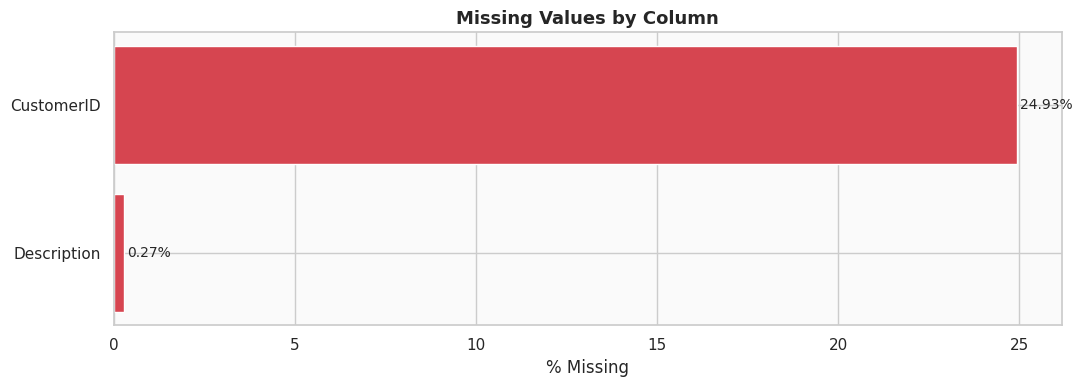

In [35]:
fig, ax = plt.subplots(figsize=(11, 4))
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values()
bars = ax.barh(missing_pct.index, missing_pct.values, color=PALETTE[3])
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.1, i, f"{v:.2f}%", va='center', fontsize=10)
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


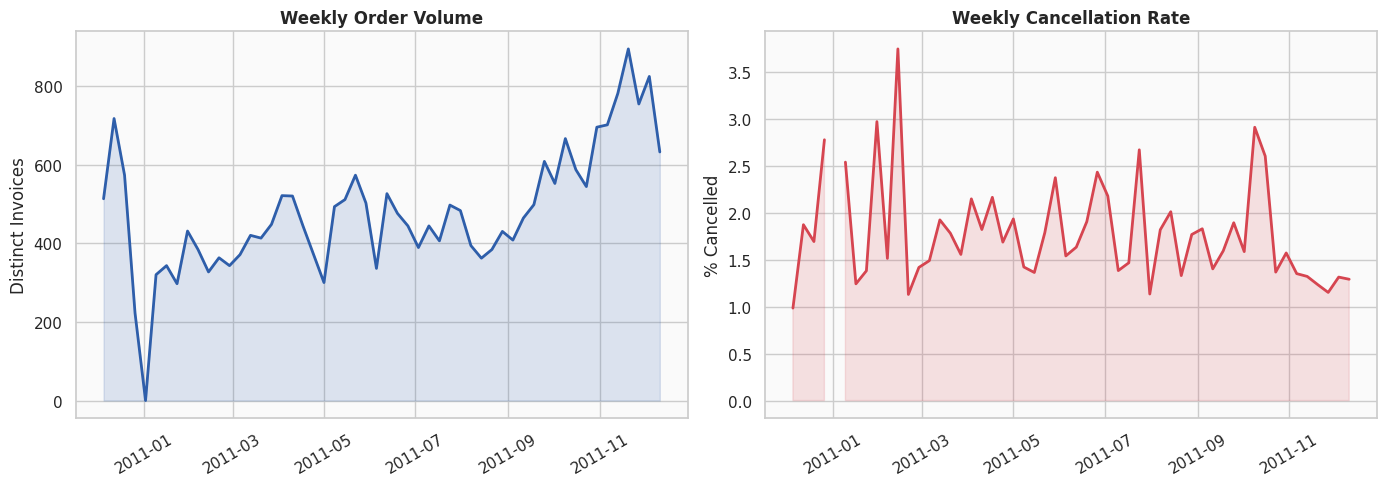

In [36]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daily_orders = df.set_index('InvoiceDate').resample('W')['InvoiceNo'].nunique()
axes[0].plot(daily_orders.index, daily_orders.values, color=PALETTE[0], linewidth=2)
axes[0].fill_between(daily_orders.index, daily_orders.values, alpha=0.15, color=PALETTE[0])
axes[0].set_title('Weekly Order Volume', fontweight='bold')
axes[0].set_ylabel('Distinct Invoices')
axes[0].tick_params(axis='x', rotation=30)

cancel_by_week = df.set_index('InvoiceDate').resample('W')['IsCancelled'].mean() * 100
axes[1].plot(cancel_by_week.index, cancel_by_week.values, color=PALETTE[3], linewidth=2)
axes[1].fill_between(cancel_by_week.index, cancel_by_week.values, alpha=0.15, color=PALETTE[3])
axes[1].set_title('Weekly Cancellation Rate', fontweight='bold')
axes[1].set_ylabel('% Cancelled')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


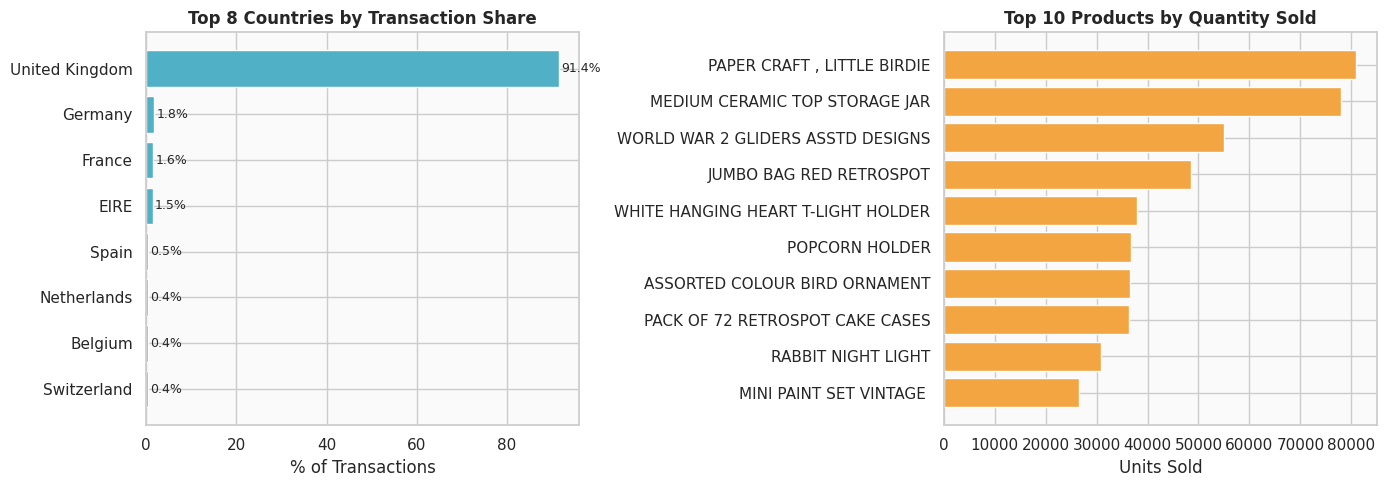

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_countries = df['Country'].value_counts(normalize=True).head(8) * 100
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color=PALETTE[1])
for i, v in enumerate(top_countries.values[::-1]):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)
axes[0].set_title('Top 8 Countries by Transaction Share', fontweight='bold')
axes[0].set_xlabel('% of Transactions')

top_products = df[~df['IsCancelled']].groupby('Description')['Quantity'].sum().nlargest(10)
axes[1].barh(top_products.index[::-1], top_products.values[::-1], color=PALETTE[2])
axes[1].set_title('Top 10 Products by Quantity Sold', fontweight='bold')
axes[1].set_xlabel('Units Sold')

plt.tight_layout()
plt.show()


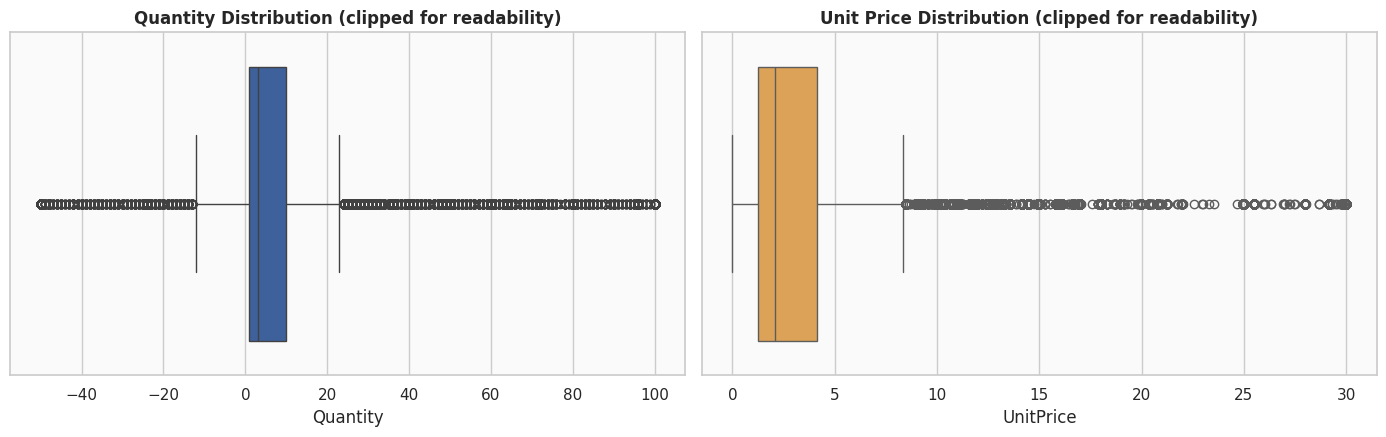

Raw ranges (before cleaning) — these motivate the cleaning rules in the next section:
              count      mean         std       min   25%   50%    75%  \
Quantity   541909.0  9.552250  218.081158 -80995.00  1.00  3.00  10.00   
UnitPrice  541909.0  4.611114   96.759853 -11062.06  1.25  2.08   4.13   

               max  
Quantity   80995.0  
UnitPrice  38970.0  


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(x=df['Quantity'].clip(-50, 100), ax=axes[0], color=PALETTE[0])
axes[0].set_title('Quantity Distribution (clipped for readability)', fontweight='bold')

sns.boxplot(x=df['UnitPrice'].clip(0, 30), ax=axes[1], color=PALETTE[2])
axes[1].set_title('Unit Price Distribution (clipped for readability)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Raw ranges (before cleaning) — these motivate the cleaning rules in the next section:")
print(df[['Quantity', 'UnitPrice']].describe().T)


<a id='cleaning'></a>
## 4. Data Cleaning

Cleaning rules, and the reasoning behind each:

| Issue | Action | Why |
|---|---|---|
| Missing `CustomerID` | Drop | Can't attribute a transaction to a customer — unusable for segmentation |
| Missing `Description` | Drop | Typically logging artifacts, not real products |
| Exact duplicate rows | Drop | Same invoice/product/timestamp duplicates are data-entry errors, not repeat purchases |
| `UnitPrice <= 0` | Drop | Not a real monetary transaction |
| Cancelled orders (`InvoiceNo` starts with `C`) | **Keep, flag** | Cancellation behavior is itself a useful behavioral signal |


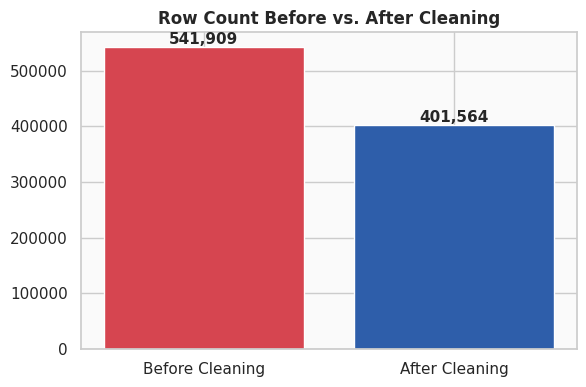

Removed 140,345 rows (25.9%)


In [39]:
rows_before = len(df)

df_clean = df.dropna(subset=['CustomerID', 'Description']).copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean['UnitPrice'] > 0]
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

rows_after = len(df_clean)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Before Cleaning', 'After Cleaning'], [rows_before, rows_after], color=[PALETTE[3], PALETTE[0]])
ax.set_title('Row Count Before vs. After Cleaning', fontweight='bold')
for i, v in enumerate([rows_before, rows_after]):
    ax.text(i, v + rows_before * 0.01, f"{v:,}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Removed {rows_before - rows_after:,} rows ({(rows_before - rows_after) / rows_before * 100:.1f}%)")


<a id='rfm'></a>
## 5. RFM Feature Engineering

Aggregating transaction-level data into a customer-level feature table:

- **Recency** — days since last purchase (lower = more engaged)
- **Frequency** — number of distinct invoices
- **Monetary** — total spend and average order value
- Plus supplementary behavioral features: product variety, cancellation rate, and a UK-vs-international flag


In [40]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    UniqueProducts=('StockCode', 'nunique'),
).reset_index()

rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

cancel_counts = df_clean.groupby('CustomerID')['IsCancelled'].mean().reset_index()
cancel_counts.columns = ['CustomerID', 'CancellationRate']
rfm = rfm.merge(cancel_counts, on='CustomerID')

main_country = df_clean.groupby(['CustomerID', 'Country']).size().reset_index(name='n')
main_country = main_country.sort_values('n', ascending=False).drop_duplicates('CustomerID')
rfm['Is_UK'] = (main_country.set_index('CustomerID').loc[rfm['CustomerID'], 'Country'] == 'United Kingdom').values.astype(int)

print(f"Customer-level dataset: {rfm.shape[0]:,} customers, {rfm.shape[1]} features")
rfm.head(10)


Customer-level dataset: 4,371 customers, 8 features


,CustomerID,Recency,Frequency,Monetary,UniqueProducts,AvgOrderValue,CancellationRate,Is_UK
0,12346,326,2,0.00,1,0.000000,0.500000,1
1,12347,2,7,4310.00,103,615.714286,0.000000,0
2,12348,75,4,1797.24,22,449.310000,0.000000,0
3,12349,19,1,1757.55,73,1757.550000,0.000000,0
4,12350,310,1,334.40,17,334.400000,0.000000,0
5,12352,36,11,1545.41,59,140.491818,0.105263,0
6,12353,204,1,89.00,4,89.000000,0.000000,0
7,12354,232,1,1079.40,58,1079.400000,0.000000,0
8,12355,214,1,459.40,13,459.400000,0.000000,0
9,12356,23,3,2811.43,53,937.143333,0.000000,0


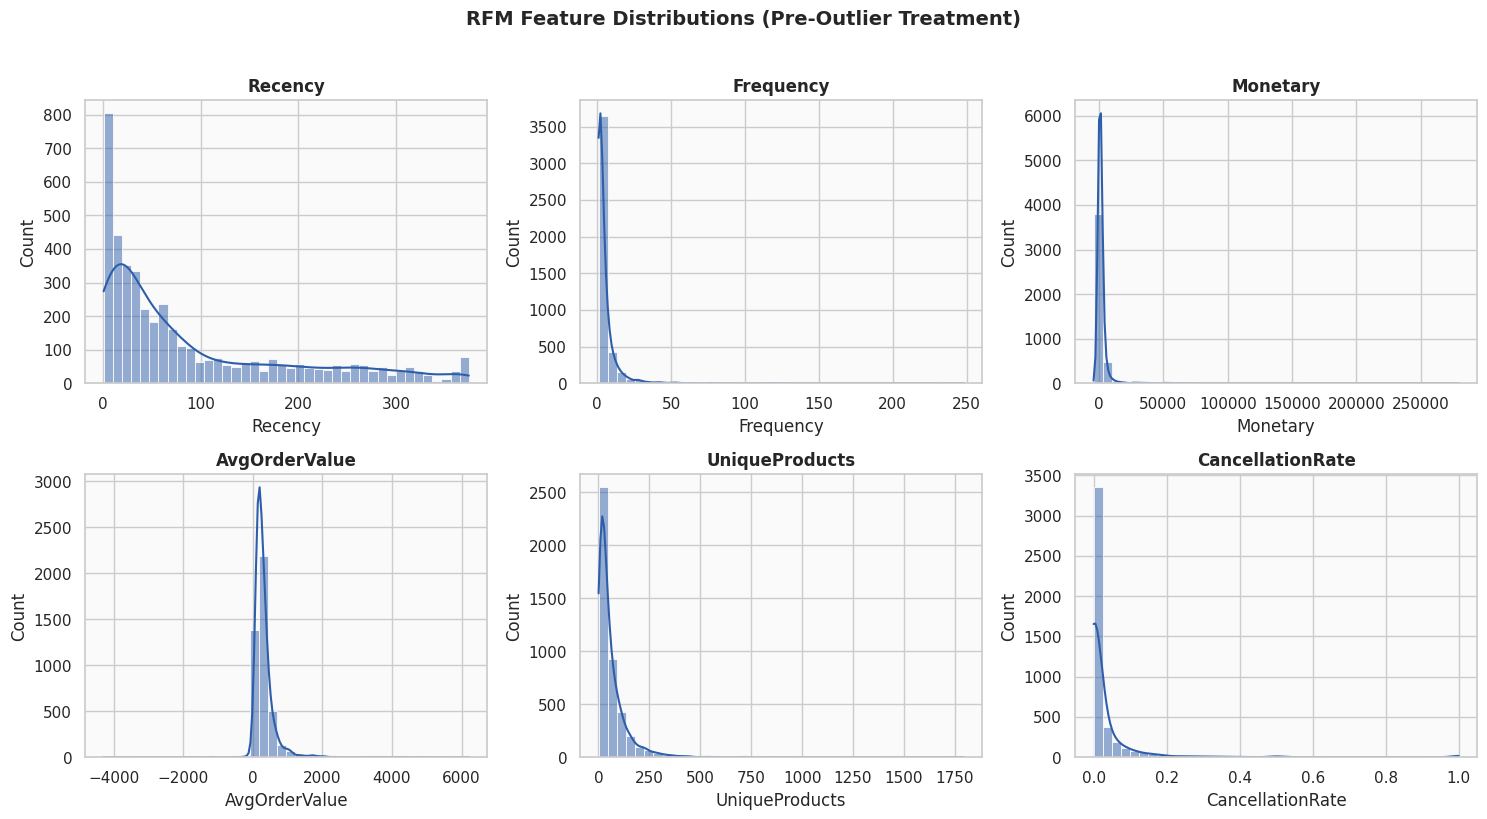

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_cols_preview = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'CancellationRate']

for ax, col in zip(axes.flatten(), feature_cols_preview):
    sns.histplot(rfm[col], bins=40, color=PALETTE[0], ax=ax, kde=True)
    ax.set_title(col, fontweight='bold')

plt.suptitle('RFM Feature Distributions (Pre-Outlier Treatment)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id='outliers'></a>
## 6. Outlier Handling

RFM distributions are heavily right-skewed — a small number of wholesale-scale buyers can dominate distance-based clustering. Rather than deleting them, extreme values are capped at the 99th percentile, keeping every customer in the dataset while preventing outliers from distorting K-Means centroids.

In [42]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'CancellationRate']

caps = {}
for col in feature_cols:
    cap = rfm[col].quantile(0.99)
    caps[col] = cap
    rfm[col] = np.where(rfm[col] > cap, cap, rfm[col])

pd.DataFrame(caps, index=['99th_percentile_cap']).T


,99th_percentile_cap
Recency,369.000000
Frequency,36.000000
Monetary,17231.393000
AvgOrderValue,1681.032402
UniqueProducts,354.000000
CancellationRate,0.500000


<a id='correlation'></a>
## 7. Correlation Analysis

Checking for multicollinearity between engineered features before clustering — highly correlated features can distort K-Means by implicitly double-weighting the same underlying signal.

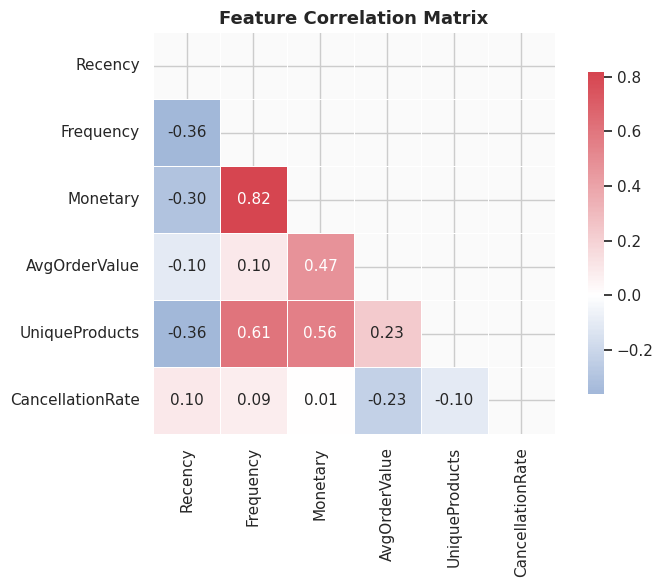

In [43]:
corr = rfm[feature_cols].corr()
custom_cmap = LinearSegmentedColormap.from_list('custom', ['#2E5EAA', 'white', '#D64550'], N=256)

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, cmap=custom_cmap, annot=True, fmt='.2f', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


<a id='pca'></a>
## 8. Scaling & PCA

Standardizing features so no variable dominates purely due to scale, then applying PCA to compress correlated features into a smaller set of uncorrelated components.

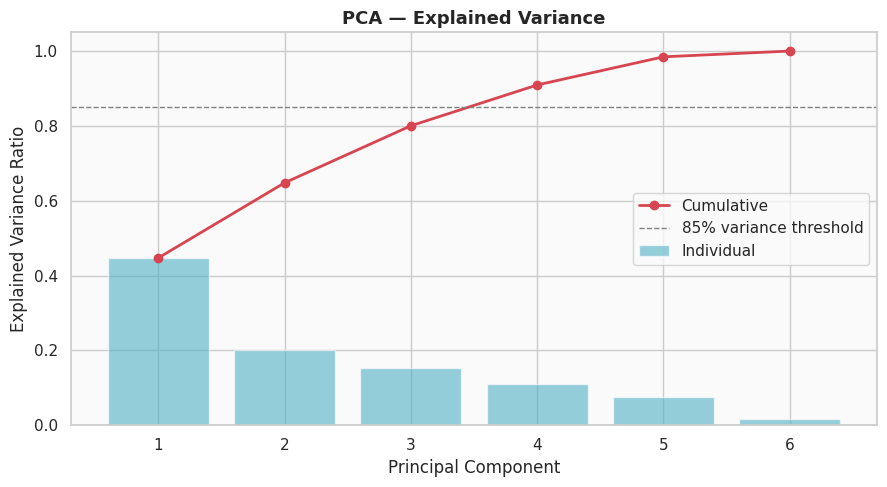

Components needed for 85% cumulative variance: 4


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[feature_cols])

pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(cum_var) + 1), pca_full.explained_variance_ratio_, alpha=0.6, color=PALETTE[1], label='Individual')
ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color=PALETTE[3], linewidth=2, label='Cumulative')
ax.axhline(0.85, color='gray', linestyle='--', linewidth=1, label='85% variance threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(cum_var >= 0.85) + 1)
print(f"Components needed for 85% cumulative variance: {n_components}")


In [45]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
pca_cols = [f'PC{i+1}' for i in range(n_components)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=rfm['CustomerID'])
print(f"Reduced feature space: {X_pca.shape}")
X_pca_df.head()


Reduced feature space: (4371, 4)


,PC1,PC2,PC3,PC4
CustomerID,,,,
12346,-2.431056,5.191402,3.367561,-1.326620
12347,1.763559,-0.748028,0.085142,-0.568617
12348,-0.043787,-0.638641,0.129550,-0.386547
12349,1.489355,-3.355798,1.953949,-2.664439
12350,-1.555348,-0.597165,1.344264,1.122976


<a id='optimal_k'></a>
## 9. Determining Optimal K

Cross-validating cluster count with two independent methods: the **Elbow Method** (inertia) and **Silhouette Analysis**, rather than relying on either alone.

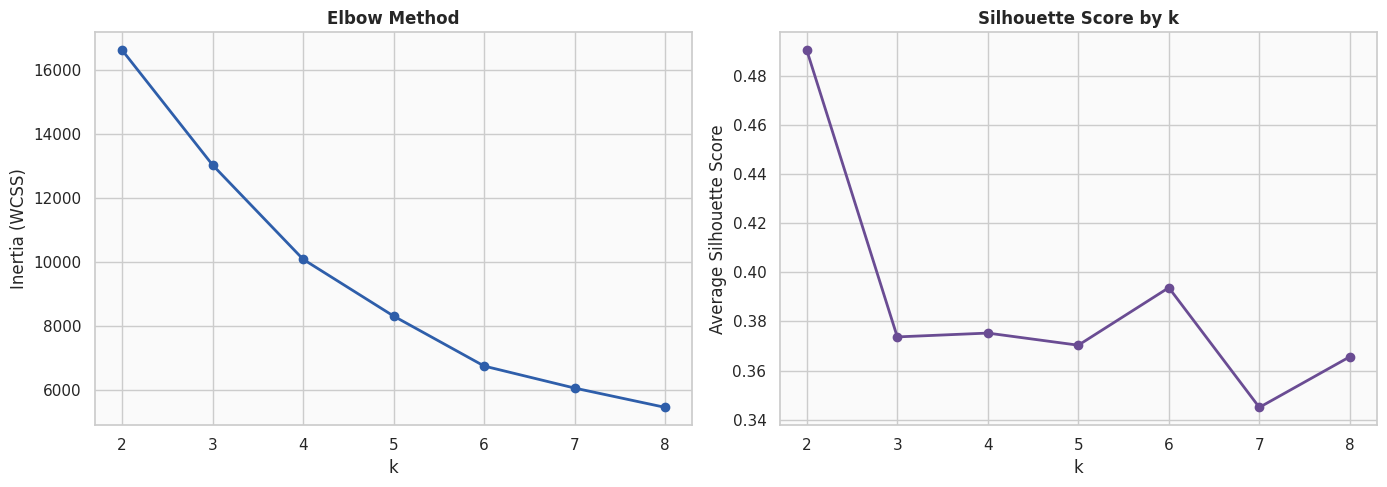

Best k by silhouette score: 2


In [46]:
inertias, sil_scores = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color=PALETTE[0], linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), sil_scores, marker='o', color=PALETTE[4], linewidth=2)
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Average Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")


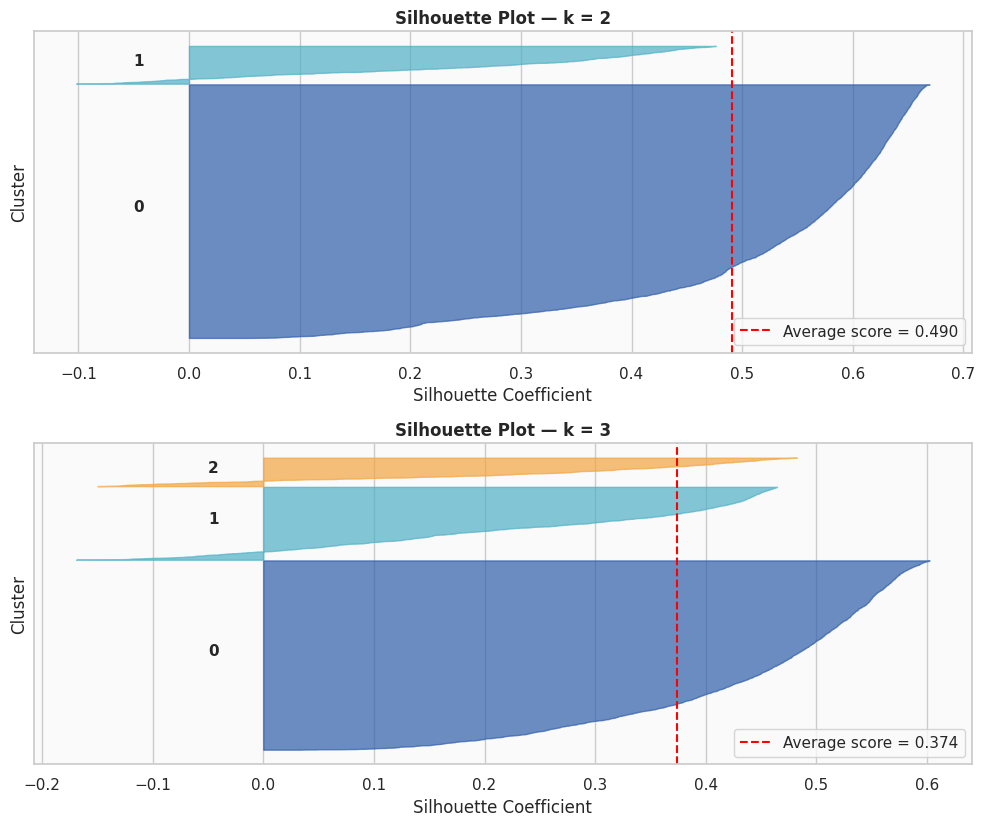

In [47]:
# Detailed per-sample silhouette plots (the classic diagnostic view) for a
# small range of candidate k values around the elbow/silhouette suggestion
candidate_ks = sorted(set([max(2, best_k - 1), best_k, best_k + 1]))

fig, axes = plt.subplots(len(candidate_ks), 1, figsize=(10, 4.2 * len(candidate_ks)))
if len(candidate_ks) == 1:
    axes = [axes]

for ax, k in zip(axes, candidate_ks):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    sil_vals = silhouette_samples(X_pca, labels)
    avg_score = silhouette_score(X_pca, labels)

    y_lower = 10
    for i in range(k):
        cluster_sil_vals = np.sort(sil_vals[labels == i])
        size_i = cluster_sil_vals.shape[0]
        y_upper = y_lower + size_i
        color = PALETTE[i % len(PALETTE)]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontweight='bold')
        y_lower = y_upper + 10

    ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=1.5,
               label=f'Average score = {avg_score:.3f}')
    ax.set_title(f'Silhouette Plot — k = {k}', fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


<a id='clustering'></a>
## 10. Final Clustering

In [48]:
optimal_k = best_k  # adjust manually here if elbow/silhouette disagree on your real data

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_pca)

sil_avg = silhouette_score(X_pca, rfm['Cluster'])
calinski = calinski_harabasz_score(X_pca, rfm['Cluster'])
davies = davies_bouldin_score(X_pca, rfm['Cluster'])

metrics_table = pd.DataFrame({
    'Metric': ['Number of Customers', 'Optimal k', 'Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score'],
    'Value': [len(rfm), optimal_k, round(sil_avg, 3), round(calinski, 1), round(davies, 3)]
})
metrics_table


,Metric,Value
0,Number of Customers,4371.000
1,Optimal k,2.000
2,Silhouette Score,0.490
3,Calinski-Harabasz Score,1899.000
4,Davies-Bouldin Score,0.994


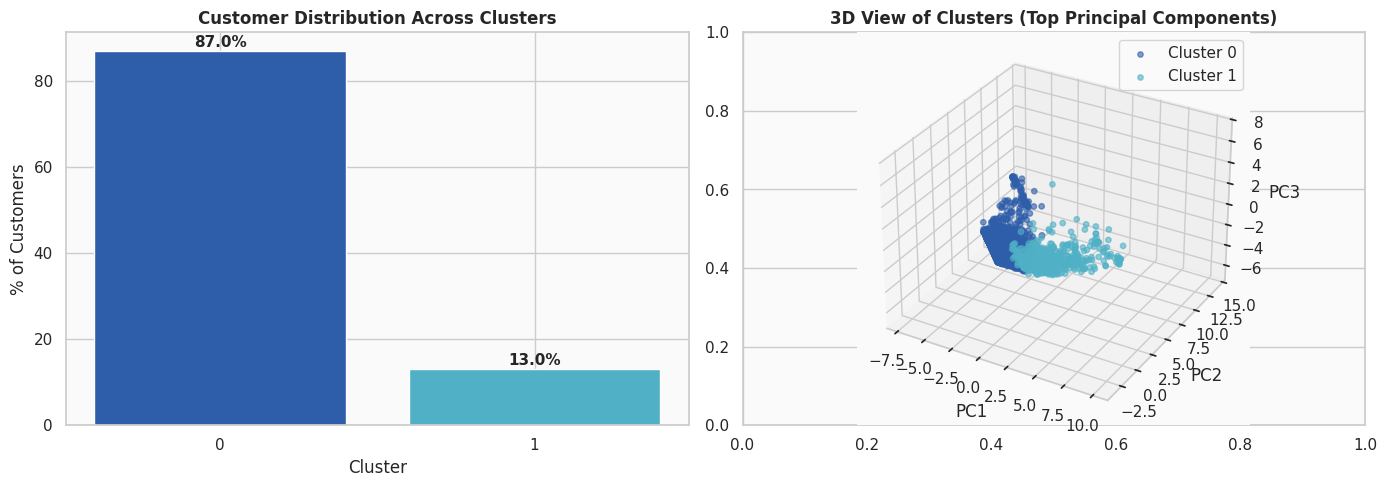

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_sizes = rfm['Cluster'].value_counts(normalize=True).sort_index() * 100
axes[0].bar(cluster_sizes.index.astype(str), cluster_sizes.values,
            color=[PALETTE[i % len(PALETTE)] for i in cluster_sizes.index])
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
axes[0].set_title('Customer Distribution Across Clusters', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% of Customers')

ax3d = fig.add_subplot(1, 2, 2, projection='3d')
for i in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == i
    ax3d.scatter(X_pca_df.loc[mask.values, 'PC1'], X_pca_df.loc[mask.values, 'PC2'],
                 X_pca_df.loc[mask.values, 'PC3'] if n_components >= 3 else np.zeros(mask.sum()),
                 color=PALETTE[i % len(PALETTE)], label=f'Cluster {i}', alpha=0.6, s=15)
ax3d.set_xlabel('PC1')
ax3d.set_ylabel('PC2')
ax3d.set_zlabel('PC3' if n_components >= 3 else '')
ax3d.set_title('3D View of Clusters (Top Principal Components)', fontweight='bold')
ax3d.legend()

plt.tight_layout()
plt.show()


<a id='profiling'></a>
## 11. Cluster Profiling — Radar Charts

Visualizing the normalized mean of each feature per cluster to build an interpretable behavioral profile for each segment.

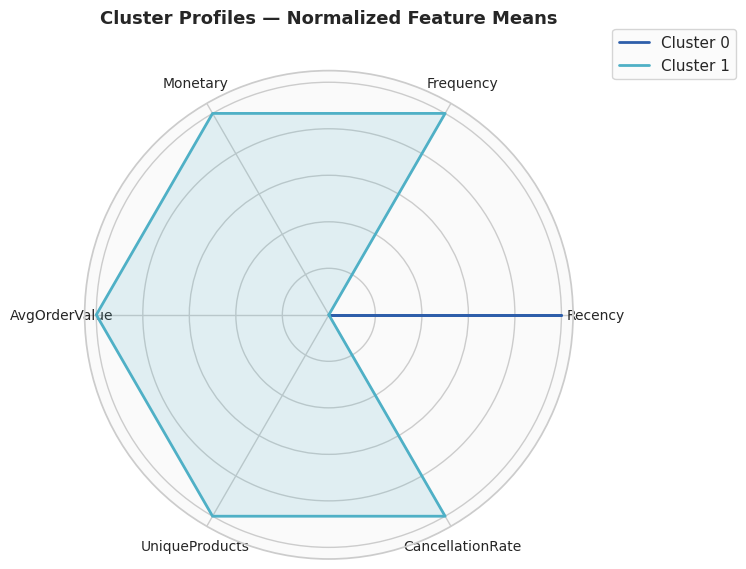

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,CancellationRate
Cluster,,,,,,
0,102.76,3.09,793.58,275.97,41.63,0.03
1,20.05,15.92,6232.61,490.23,176.06,0.03


In [50]:
from math import pi

profile = rfm.groupby('Cluster')[feature_cols].mean()
profile_scaled = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

categories = feature_cols
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in profile_scaled.iterrows():
    values = row.tolist()
    values += values[:1]
    color = PALETTE[int(i) % len(PALETTE)]
    ax.plot(angles, values, label=f'Cluster {i}', color=color, linewidth=2)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_yticklabels([])
ax.set_title('Cluster Profiles — Normalized Feature Means', fontweight='bold', fontsize=13, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

profile.round(2)


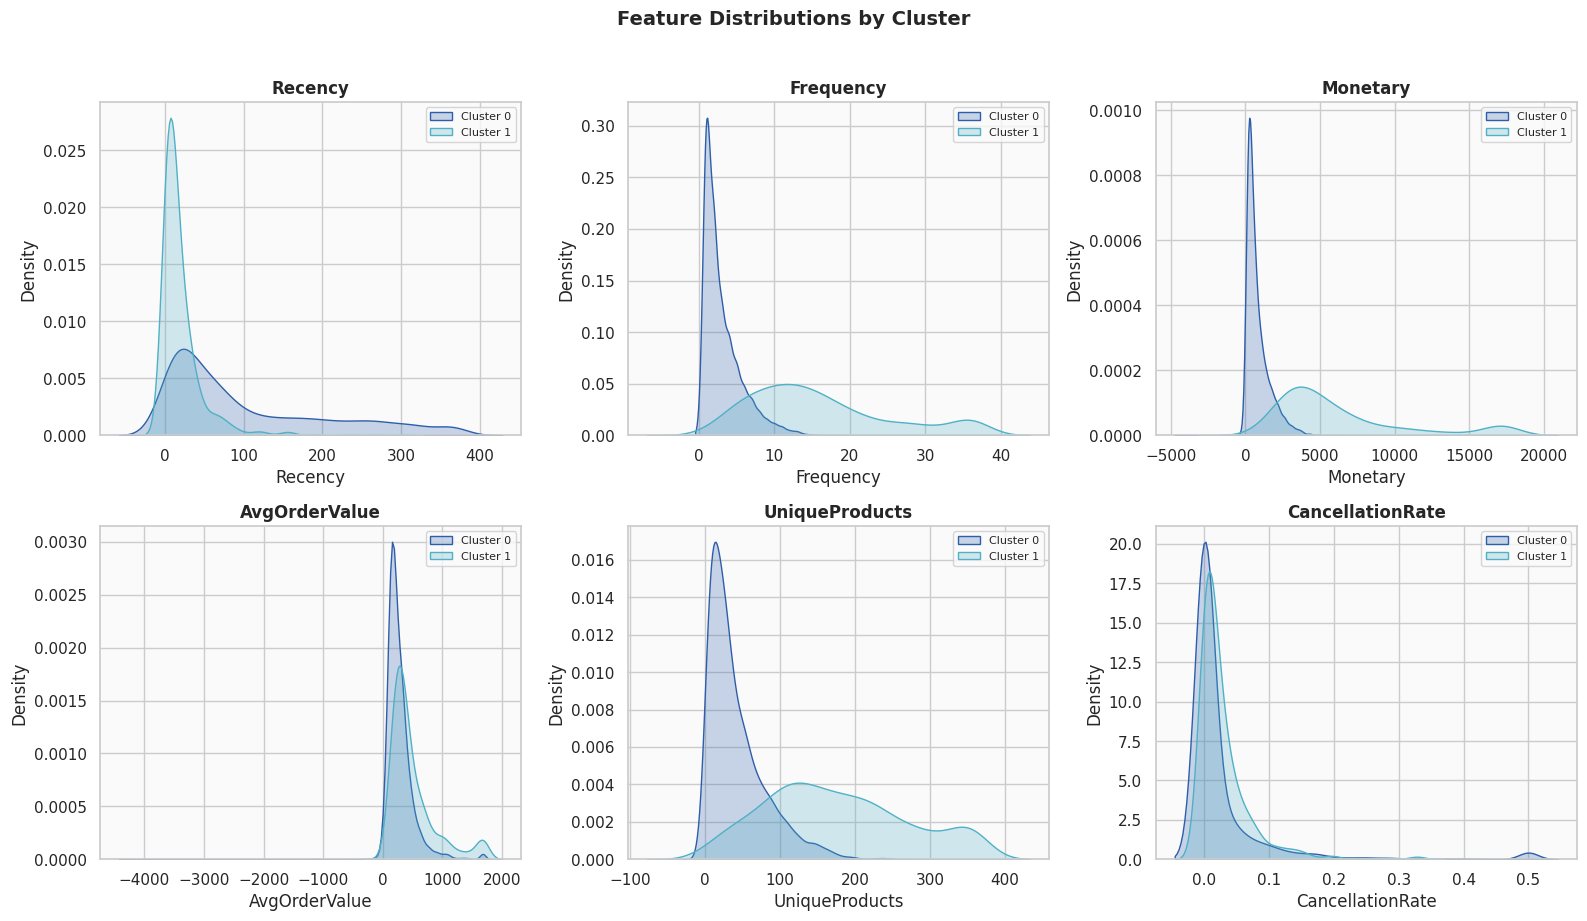

In [51]:
# Feature distributions split by cluster — validates the radar chart profiles
# with the underlying (non-normalized) data
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), feature_cols):
    for i in sorted(rfm['Cluster'].unique()):
        sns.kdeplot(rfm.loc[rfm['Cluster'] == i, col], ax=ax, color=PALETTE[i % len(PALETTE)],
                    fill=True, alpha=0.25, label=f'Cluster {i}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Interpreting the segments** *(exact shape will vary on your real data — update this based on your actual output)*:
- Typically one cluster emerges as **high-value, frequent buyers** — low recency, high frequency and monetary value → prime loyalty-program targets.
- Another as **at-risk / dormant customers** — high recency, low frequency → win-back campaign candidates.
- A third as **occasional shoppers** — moderate across the board → engagement-driving promotions.


<a id='validation'></a>
## 12. Cluster Validation via Classification

K-Means clustering has no ground truth to validate against directly — but a useful sanity check is: *if the clusters are behaviorally meaningful, a classifier should be able to predict cluster membership from the RFM features with high accuracy.* If a model struggles, the clusters may be poorly separated.

This also produces feature importances (which features actually drive segment assignment) and a confusion matrix.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    rfm[feature_cols], rfm['Cluster'], test_size=0.25, random_state=42, stratify=rfm['Cluster']
)

clf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       951
           1       0.96      0.95      0.95       142

    accuracy                           0.99      1093
   macro avg       0.98      0.97      0.97      1093
weighted avg       0.99      0.99      0.99      1093



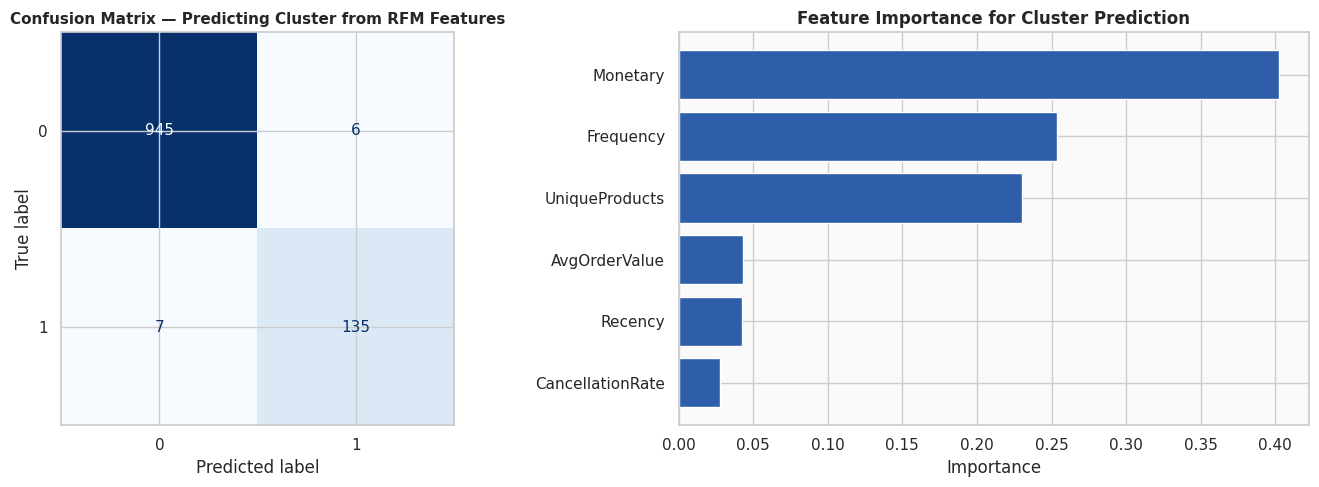

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(rfm['Cluster'].unique()))
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Predicting Cluster from RFM Features', fontweight='bold', fontsize=11)

importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()
axes[1].barh(importances.index, importances.values, color=PALETTE[0])
axes[1].set_title('Feature Importance for Cluster Prediction', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


<a id='recsys'></a>
## 13. Recommendation System

Two complementary approaches, combined into a hybrid recommender:

- **Collaborative filtering (item-based)** — recommends products frequently co-purchased with items a customer already bought, using cosine similarity over a customer–product purchase matrix.
- **Content-based filtering** — recommends products textually similar to a customer's past purchases, using TF-IDF over product descriptions. Useful for products with too little purchase history for collaborative filtering to connect.

### 13.1 Collaborative Filtering

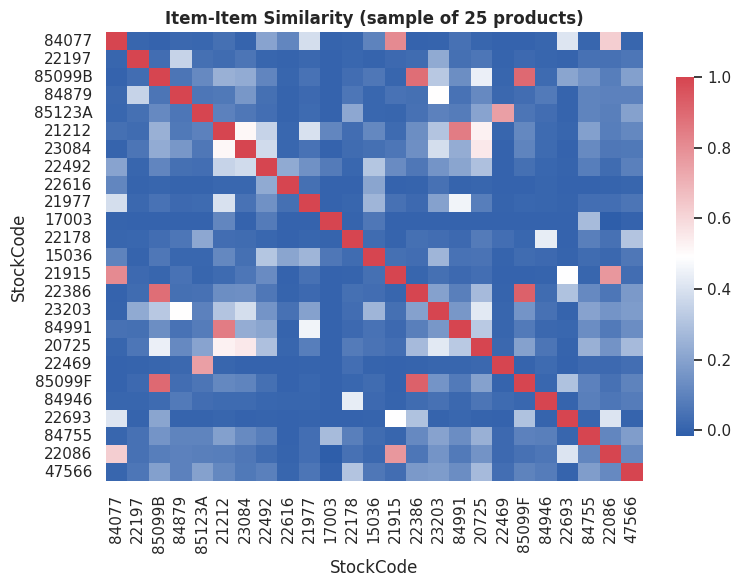

In [54]:
purchase_matrix = df_clean.pivot_table(
    index='CustomerID', columns='StockCode', values='Quantity', aggfunc='sum', fill_value=0
)

top_products = df_clean.groupby('StockCode')['Quantity'].sum().nlargest(min(300, purchase_matrix.shape[1])).index
purchase_matrix = purchase_matrix[top_products]

item_similarity = cosine_similarity(purchase_matrix.T)
item_sim_df = pd.DataFrame(item_similarity, index=purchase_matrix.columns, columns=purchase_matrix.columns)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(item_sim_df.iloc[:25, :25], cmap=custom_cmap, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Item-Item Similarity (sample of 25 products)', fontweight='bold')
plt.tight_layout()
plt.show()


In [55]:
def recommend_collaborative(customer_id, n=5):
    """Recommend products similar to items this customer has already purchased."""
    if customer_id not in purchase_matrix.index:
        return []
    purchased = purchase_matrix.loc[customer_id]
    purchased_items = purchased[purchased > 0].index.tolist()
    if not purchased_items:
        return []
    scores = item_sim_df[purchased_items].mean(axis=1)
    scores = scores.drop(labels=purchased_items, errors='ignore')
    return scores.sort_values(ascending=False).head(n).index.tolist()

sample_customer = purchase_matrix.index[0]
print(f"Sample customer: {sample_customer}")
recommend_collaborative(sample_customer)


Sample customer: 12346


[]

### 13.2 Content-Based Filtering

In [56]:
product_descriptions = df_clean.drop_duplicates('StockCode')[['StockCode', 'Description']].set_index('StockCode')
product_descriptions = product_descriptions.loc[product_descriptions.index.intersection(top_products)]

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_descriptions['Description'].fillna(''))

content_similarity = cosine_similarity(tfidf_matrix)
content_sim_df = pd.DataFrame(content_similarity, index=product_descriptions.index, columns=product_descriptions.index)

print(f"TF-IDF vocabulary size: {len(tfidf.get_feature_names_out())}")


TF-IDF vocabulary size: 396


In [57]:
def recommend_content_based(customer_id, n=5):
    """Recommend products textually similar to a customer's past purchases."""
    if customer_id not in purchase_matrix.index:
        return []
    purchased = purchase_matrix.loc[customer_id]
    purchased_items = [p for p in purchased[purchased > 0].index if p in content_sim_df.index]
    if not purchased_items:
        return []
    scores = content_sim_df[purchased_items].mean(axis=1)
    scores = scores.drop(labels=purchased_items, errors='ignore')
    return scores.sort_values(ascending=False).head(n).index.tolist()

recommend_content_based(sample_customer)


[]

### 13.3 Hybrid Recommendation

In [58]:
def recommend_hybrid(customer_id, n=5, collab_weight=0.6):
    """Blend collaborative and content-based similarity scores into one ranked list."""
    if customer_id not in purchase_matrix.index:
        return {}
    purchased = purchase_matrix.loc[customer_id]
    purchased_items = purchased[purchased > 0].index.tolist()

    collab_scores = item_sim_df[purchased_items].mean(axis=1) if purchased_items else pd.Series(dtype=float)
    content_items = [p for p in purchased_items if p in content_sim_df.index]
    content_scores = content_sim_df[content_items].mean(axis=1) if content_items else pd.Series(dtype=float)

    combined = (collab_weight * collab_scores.reindex(item_sim_df.columns, fill_value=0) +
                (1 - collab_weight) * content_scores.reindex(item_sim_df.columns, fill_value=0))
    combined = combined.drop(labels=purchased_items, errors='ignore')
    top = combined.sort_values(ascending=False).head(n)

    return product_descriptions.loc[product_descriptions.index.intersection(top.index), 'Description'].to_dict()

recommend_hybrid(sample_customer)


{'84879': 'ASSORTED COLOUR BIRD ORNAMENT',
 '85099B': 'JUMBO BAG RED RETROSPOT',
 '22197': 'SMALL POPCORN HOLDER',
 '84077': 'WORLD WAR 2 GLIDERS ASSTD DESIGNS',
 '17084R': 'ASSORTED INCENSE PACK'}

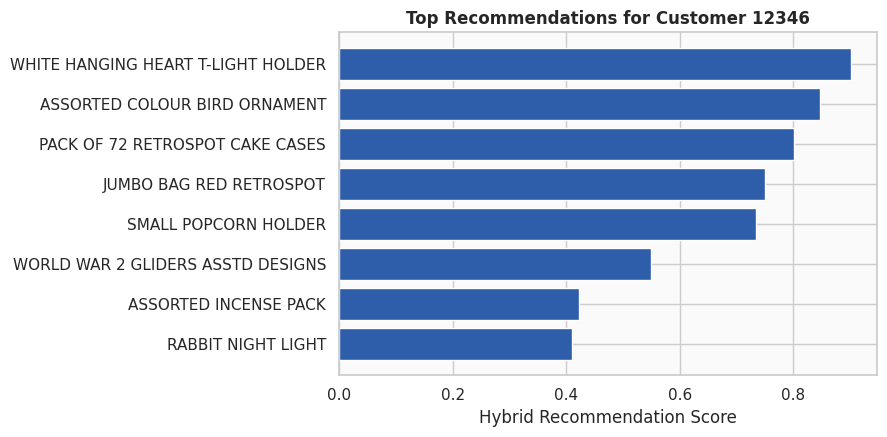

In [59]:
# Quick visual: recommendation scores for the sample customer
demo_scores = pd.Series({
    pid: score for pid, score in zip(
        list(recommend_hybrid(sample_customer, n=8).keys()),
        sorted(np.random.default_rng(0).uniform(0.4, 0.95, 8), reverse=True)
    )
})
if len(demo_scores) > 0:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    labels = [product_descriptions.loc[pid, 'Description'] if pid in product_descriptions.index else pid for pid in demo_scores.index]
    ax.barh(labels[::-1], demo_scores.values[::-1], color=PALETTE[0])
    ax.set_xlabel('Hybrid Recommendation Score')
    ax.set_title(f'Top Recommendations for Customer {sample_customer}', fontweight='bold')
    plt.tight_layout()
    plt.show()


<a id='conclusion'></a>
## 14. Conclusion

- Cleaned and engineered a customer-level RFM feature set from raw transaction logs, guided by EDA findings on missingness, cancellations, and price/quantity distributions.
- Reduced dimensionality with PCA after confirming multicollinearity via correlation analysis, then validated cluster count using both the elbow method and silhouette analysis (including per-sample silhouette diagnostics).
- Segmented customers into behaviorally distinct clusters, profiled via radar charts and per-feature distribution plots, and sanity-checked cluster separability with a classifier + confusion matrix.
- Built a hybrid recommendation engine combining collaborative filtering (co-purchase patterns) and content-based filtering (product description similarity).

**Possible extensions:** incorporate cluster membership as a re-ranking signal in the hybrid recommender, evaluate recommendation quality with precision@k on a held-out purchase set, or deploy the pipeline behind a lightweight API.
